In [1]:
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 55.2 MB/s eta 0:00:00


In [ ]:
# Install only if needed
try:
    import rdkit
    from rdkit import Chem
    from rdkit.Chem import Draw, Descriptors, Crippen, rdMolDescriptors
except Exception:
    %pip install rdkit

In [2]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from rdkit.Chem import PandasTools
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw, Descriptors, Crippen, rdMolDescriptors

# Aspirin

In [ ]:
smi = "CC(=O)OC1=CC=CC=C1C(=O)O"  # aspirin
mol = Chem.MolFromSmiles(smi)
Draw.MolToImage(mol, size=(300, 200))

# Add hydrogens for clarity

In [ ]:
mol_H = Chem.AddHs(mol)
Draw.MolToImage(mol_H, size=(350, 250))

# Quick properties in one place

In [ ]:
mw = Descriptors.MolWt(mol)
logp = Crippen.MolLogP(mol)
hbd = rdMolDescriptors.CalcNumHBD(mol)
hba = rdMolDescriptors.CalcNumHBA(mol)
tpsa = rdMolDescriptors.CalcTPSA(mol)
print("MolWt", round(mw,2), "LogP", round(logp,2), "HBD", hbd, "HBA", hba, "TPSA", round(tpsa,1))

In [ ]:
# Show atom numbers to plan edits
options = Draw.MolDrawOptions()
options.addAtomIndices = True

img = Draw.MolToImage(
    mol,
    size=(350, 250),
    options=options
)
img

In [ ]:
qry = Chem.MolFromSmiles("Cl")     # what to find
rep = Chem.MolFromSmiles("F")      # what to place
mol = Chem.MolFromSmiles("Clc1ccc(cc1)C(=O)O")

rep_mol = Chem.ReplaceSubstructs(mol, qry, rep, replaceAll=True)[0]
Draw.MolToImage(rep_mol, size=(350, 250))

In [ ]:
mol = Chem.MolFromSmiles("CC(=O)[O-]")
find = Chem.MolFromSmiles("[O-]")  # anionic oxygen as a molecule
put  = Chem.MolFromSmiles("O")
mol_neutral = Chem.ReplaceSubstructs(mol, find, put, replaceAll=True)[0]
Draw.MolToImage(mol_neutral, size=(320, 220))

In [ ]:
mol = Chem.MolFromSmiles("Oc1ccccc1")  # benzene
em = Chem.EditableMol(mol)

idx_C = em.AddAtom(Chem.Atom("C"))
idx_H1 = em.AddAtom(Chem.Atom("H"))
idx_H2 = em.AddAtom(Chem.Atom("H"))
idx_H3 = em.AddAtom(Chem.Atom("H"))

em.AddBond(2, idx_C, order=Chem.BondType.SINGLE)  # attach at atom index 2
em.AddBond(idx_C, idx_H1, order=Chem.BondType.SINGLE)
em.AddBond(idx_C, idx_H2, order=Chem.BondType.SINGLE)
em.AddBond(idx_C, idx_H3, order=Chem.BondType.SINGLE)

mol_new = em.GetMol()
Chem.SanitizeMol(mol_new)
options = Draw.MolDrawOptions()
options.addAtomIndices = True

Draw.MolToImage(
    mol_new,
    size=(350, 250),
    options=options
)

# Sanitize

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# This example demonstrates Chem.SanitizeMol() assigning a formal charge to correct valency.

# Create a carbon atom using EditableMol. By default, it's neutral with zero bonds initially.
# We will explicitly add 3 single bonds, making it appear trivalent but neutral,
# which is an unstable, short-lived species (a carbocation needs a positive charge).
init_mol = Chem.MolFromSmiles('[C]') # Atom 0: Carbon. Corrected from '[CC]' to '[C]'
em = Chem.EditableMol(init_mol)

# Add three hydrogens to the carbon
idx_H1 = em.AddAtom(Chem.Atom('H'))
idx_H2 = em.AddAtom(Chem.Atom('H'))
idx_H3 = em.AddAtom(Chem.Atom('H'))

em.AddBond(0, idx_H1, order=Chem.BondType.SINGLE)
em.AddBond(0, idx_H2, order=Chem.BondType.SINGLE)
em.AddBond(0, idx_H3, order=Chem.BondType.SINGLE)

# Get the molecule before sanitization
unsanitized_carbocation = em.GetMol()

print("Molecule before sanitization (explicit bonds: 3, neutral C):")
# Display the molecule. RDKit might draw it as neutral if not sanitized or charge not explicitly set.
display(Draw.MolToImage(unsanitized_carbocation, size=(200, 150)))
print(f"Formal Charge of C (before sanitize): {unsanitized_carbocation.GetAtomWithIdx(0).GetFormalCharge()}")

# Now, sanitize the molecule. Chem.SanitizeMol() will identify that a carbon with 3 single bonds
# should have a +1 formal charge to satisfy chemical valency rules (like in a carbocation).
Chem.SanitizeMol(unsanitized_carbocation)

#print("\nMolecule after sanitization (RDKit assigns +1 formal charge to C):")
display(Draw.MolToImage(unsanitized_carbocation, size=(200, 150)))
print(f"Formal Charge of C (after sanitize): {unsanitized_carbocation.GetAtomWithIdx(0).GetFormalCharge()}")

# Explanation:
# Before sanitization, we explicitly created a carbon atom with 3 single bonds, but it was still marked as neutral.
#Chem.SanitizeMol() recognized that a carbon with 3 explicit single bonds must carry a positive formal charge
# to be chemically valid (e.g., a methyl cation). It automatically assigned this +1 formal charge, making the molecule chemically consistent.
# This demonstrates how SanitizeMol corrects valency by inferring and applying formal charges when appropriate.

# Creates a mol object from a SMILEs string.

In [ ]:
dataset = pd.read_csv('https://raw.githubusercontent.com/qckb/Data-course/main/Orbital_Energies_input_data.csv')
dataset.head(10)

In [ ]:
#dataset = dataset[['SMILES','Energygap']]
PandasTools.AddMoleculeColumnToFrame(dataset, smilesCol='SMILES')

In [ ]:
display(dataset.head())

In [ ]:
first_smile = dataset["SMILES"][0]
print(first_smile)

In [ ]:
mol_object = Chem.MolFromSmiles(first_smile,sanitize=True)

In [ ]:
type(mol_object)

In [ ]:
mol_object

In [ ]:
# Define your SMILES string (e.g., Ethanol)
#smiles_string = "CCO"

# Create the RDKit Mol object
#mol = Chem.MolFromSmiles(smiles_string)



# Verify creation by checking if the object exists
#if mol is not None:
#    print("Mol object successfully created!")
#else:
#    print("Invalid SMILES string.")


# Convert a mole object to a SMILEs string. Mol objects are useful because, unlike SMILEs strings, they can be rendered as 2D and 3D objects.

In [ ]:
Chem.MolToSmiles(mol_object)

In [ ]:
mol_object.GetNumAtoms()
Descriptors.MolWt(mol_object)
Crippen.MolLogP(mol_object)

In [ ]:
print(Chem.MolToMolBlock(mol_object))

In [ ]:
mol_object_3D = Chem.AddHs(mol_object) # by default rdkit's mol object does not store H's
AllChem.EmbedMolecule(mol_object_3D)

In [ ]:
mol_object_3D

In [ ]:
print(Chem.MolToMolBlock(mol_object_3D))

# Fingerprint

In [3]:
from rdkit.Chem import rdFingerprintGenerator
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)

methane = Chem.MolFromSmiles("C") # replace with other SMILES strings to see how it changes!
caffeine = Chem.MolFromSmiles("Cn1cnc2c1c(=O)n(C)c(=O)n2C")
fp_me = mfpgen.GetFingerprint(methane)
fp_caff = mfpgen.GetFingerprint(caffeine)

from rdkit import DataStructs
print(fp_me.ToBitString())
print("##")
print(fp_caff.ToBitString())

00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000010000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
##
1000000000000000000000000000000001000000000000000000100000000000000000000000000000000000000000000000000000000000000000000100000000000000001000000000000000000000100000000000000000010000000000000000000000000000000000000000000000000000001000000000000000000000000100000000000000000000000100000000000000000000000000000010000000000000001000000100000000000000000010000000000000000000001000000100000000000000100000000000000010001001000010000000000000000000000000000000000100000000000000000000

In [5]:
import pandas as pd
from rdkit.Chem import PandasTools

url = "https://raw.githubusercontent.com/qckb/Data-course/main/organic_ligands_inventory_smiles.xlsx"

df = pd.read_excel(url, engine="openpyxl")
df = df[['Compound ID','smiles','MW']]


PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles', molCol='Mol')
df.head()

,Compound ID,smiles,MW,Mol
0,2-Methylimidazole,CC1=NC=CN1,82.106,<rdkit.Chem.rdchem.Mol object at 0x7b14b31c9930>
1,1-Ethyl-3-vinylimidazolium bromide,C=C[N+]1=CN(CC)C=C1.[Br-],203.083,<rdkit.Chem.rdchem.Mol object at 0x7b14b31c8040>
2,"1-Methyl-1,4-diazabicyclo[2.2.2]octan-1-iumchl...",[Cl-].N12CC[N+](C)(CC1)CC2,162.660,<rdkit.Chem.rdchem.Mol object at 0x7b14b31c98c0>
3,Oxazole-4-carboxylic acid,O=C(C1=COC=N1)O,113.072,<rdkit.Chem.rdchem.Mol object at 0x7b14b31e0f90>
4,3-Ethyl-2-methylbenzo[d]thiazol-3-ium iodide,CC[N+]1=C(C)SC2=CC=CC=C21.[I-],305.184,<rdkit.Chem.rdchem.Mol object at 0x7b14b31e0eb0>


In [6]:
def canonicalize(smiles):
    m = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(m) if m else None

df['canonical_smiles'] = df['smiles'].apply(canonicalize)

In [7]:
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator

desc_names = ['MolWt','TPSA','MolLogP','NumHAcceptors','NumHDonors']
calc = MolecularDescriptorCalculator(desc_names)

df_desc = df['Mol'].apply(calc.CalcDescriptors)
df_desc = pd.DataFrame(df_desc.tolist(), columns=desc_names)

df_all = pd.concat([df[['Compound ID','MW','canonical_smiles']], df_desc], axis=1)
df_all.head()

,Compound ID,MW,canonical_smiles,MolWt,TPSA,MolLogP,NumHAcceptors,NumHDonors
0,2-Methylimidazole,82.106,Cc1ncc[nH]1,82.106,28.68,0.71812,1,1
1,1-Ethyl-3-vinylimidazolium bromide,203.083,C=C[n+]1ccn(CC)c1.[Br-],203.083,8.81,-2.10000,0,0
2,"1-Methyl-1,4-diazabicyclo[2.2.2]octan-1-iumchl...",162.660,C[N+]12CCN(CC1)CC2.[Cl-],162.664,3.24,-3.23380,1,0
3,Oxazole-4-carboxylic acid,113.072,O=C(O)c1cocn1,113.072,63.33,0.37280,3,1
4,3-Ethyl-2-methylbenzo[d]thiazol-3-ium iodide,305.184,CC[n+]1c(C)sc2ccccc21.[I-],305.184,3.88,-0.47888,1,0


In [8]:
df_clean = df_all.dropna()
print("Number of rows after cleaning:", len(df_clean))

Number of rows after cleaning: 102


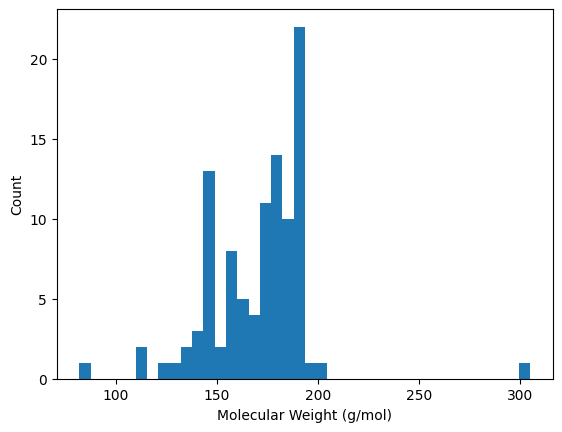

In [9]:
import matplotlib.pyplot as plt

plt.hist(df_clean['MolWt'], bins=40)
plt.xlabel("Molecular Weight (g/mol)")
plt.ylabel("Count")
plt.show()